In [14]:
# Células para integrar no seu notebook behaviourRugsMarkovStorm.ipynb
# ---------------------------------------------------------------
# Objetivo: carregar dados (./mnt/data/storms.csv), renomear colunas,
# discretizar speed, direction, wind e pressure, montar símbolo composto,
# construir alfabeto, calcular matriz de transição (cadeia de Markov)
# e salvar/visualizar resultados.

# --- Célula 1: imports e leitura ---
import pandas as pd
import numpy as np
from collections import Counter, defaultdict

# configuração: caminho do arquivo (ajuste se necessário)
CSV_PATH = "storms.csv"

# Leitura do CSV
df = pd.read_csv(CSV_PATH)

# Renomeações básicas (caso ainda não tenham sido feitas)
rename_map = {"lat": "x", "long": "y", "name": "trajectory_id"}
for c_old, c_new in rename_map.items():
    if c_old in df.columns and c_new not in df.columns:
        df = df.rename(columns={c_old: c_new})

# Se você já gerou a coluna timestamp antes, esta parte mantém.
if not "timestamp" in df.columns:
    if set(["month","day","hour"]).issubset(df.columns):
        df["timestamp"] = (
            df["month"].astype(int) * 10_000 +
            df["day"].astype(int) * 100 +
            df["hour"].astype(int)
        )
    else:
        # caso não existam as colunas, cria timestamp incremental por trajectory
        df = df.sort_values(["trajectory_id", "year", "month", "day", "hour"], errors='ignore')
        df["timestamp"] = df.groupby("trajectory_id").cumcount()



df['x_translate'] = df.groupby('trajectory_id')['x'].transform(lambda x: x - x.iloc[0])
df['y_translate'] = df.groupby('trajectory_id')['y'].transform(lambda y: y - y.iloc[0])

angles = {}

def pca_angle(x, y):
    X = np.vstack([x, y]).T
    Xc = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0]
    disp = np.array([x[-1], y[-1]])
    if np.dot(v1, disp) < 0:
        v1 = -v1
    return np.arctan2(v1[1], v1[0])

df['x_rotated'] = np.nan
df['y_rotated'] = np.nan

for tid, g in df.groupby('trajectory_id'):
    x, y = g['x_translate'].to_numpy(), g['y_translate'].to_numpy()
    theta = pca_angle(x, y)
    c, s = np.cos(-theta), np.sin(-theta)
    xr = x * c - y * s
    yr = x * s + y * c
    df.loc[g.index, 'x_rotated'] = xr
    df.loc[g.index, 'y_rotated'] = yr
    angles[tid] = theta


df = df.sort_values(["trajectory_id", "timestamp"]).reset_index(drop=True)
window = 1

def compute_speed_angle(g):
    dx = g["x_rotated"] - g["x_rotated"].shift(window)
    dy = g["y_rotated"] - g["y_rotated"].shift(window)
    g["speed"] = np.hypot(dx, dy)
    g["angle_deg"] = np.degrees(np.arctan2(dy, dx))
    return g

df = df.groupby("trajectory_id", group_keys=False).apply(compute_speed_angle)
# --- Célula 2: função de discretização robusta ---

def discretizar_serie_qcut(series, n_bins=5, prefix="V", duplicates_method="drop"):
    """Discretiza uma série usando quantis. Retorna uma série de rótulos.
    duplicates_method: 'drop' (default) tenta reduzir bins quando valores constantes,
    'uniform' cria bins uniformes via pd.cut como fallback.
    """
    s = series.copy()
    # tratar NA
    na_mask = s.isna()
    try:
        labels = [f"{prefix}{i}" for i in range(n_bins)]
        binned = pd.qcut(s, q=n_bins, labels=labels, duplicates='drop')
        # se qcut reduziu o número de bins por duplicates, alinhamos labels existentes
        return binned.astype(str).where(~na_mask, other=np.nan)
    except Exception:
        # fallback: bins uniformes
        if duplicates_method == "uniform":
            labels = [f"{prefix}{i}" for i in range(n_bins)]
            binned = pd.cut(s, bins=n_bins, labels=labels)
            return binned.astype(str).where(~na_mask, other=np.nan)
        else:
            # fallback que reduz n_bins até qcut funcionar
            for k in range(n_bins, 1, -1):
                try:
                    labels = [f"{prefix}{i}" for i in range(k)]
                    binned = pd.qcut(s, q=k, labels=labels, duplicates='drop')
                    return binned.astype(str).where(~na_mask, other=np.nan)
                except Exception:
                    continue
            # como último recurso, retorna valores discretizados por rangos simples
            median = s.median()
            return s.apply(lambda v: f"{prefix}0" if v<=median else f"{prefix}1").where(~na_mask, other=np.nan)

# --- Célula 3: criar símbolos para as 4 variáveis ---
# Ajuste n_bins conforme desejar (ex.: 5)
N_BINS_SPEED = 5
N_BINS_WIND = 5
N_BINS_PRESSURE = 5

# nome das colunas que esperamos no seu dataset (altere se difere)
SPEED_COL = "speed"
DIR_COL = "direction_symbol"  # supondo que você já tenha a coluna simbólica para direção
WIND_COL = "wind"
PRESSURE_COL = "pressure"

# Se não houver direction_symbol, tente criar uma a partir de 'direction' em graus
if DIR_COL not in df.columns and "direction" in df.columns:
    # converte graus em rótulos simplificados (N, L, S, O)
    def deg_to_octant(deg):
        try:
            deg = float(deg) % 360
        except Exception:
            return np.nan
        octants = ['N','L','S','O']
        idx = int((deg + 22.5) // 45) % 4
        return octants[idx]
    df[DIR_COL] = df['direction'].apply(deg_to_octant)

# Discretizar speed, wind, pressure
if SPEED_COL in df.columns:
    df['sym_speed'] = discretizar_serie_qcut(df[SPEED_COL], n_bins=N_BINS_SPEED, prefix='S')
else:
    df['sym_speed'] = np.nan

if WIND_COL in df.columns:
    df['sym_wind'] = discretizar_serie_qcut(df[WIND_COL], n_bins=N_BINS_WIND, prefix='W')
else:
    df['sym_wind'] = np.nan

if PRESSURE_COL in df.columns:
    df['sym_pressure'] = discretizar_serie_qcut(df[PRESSURE_COL], n_bins=N_BINS_PRESSURE, prefix='P')
else:
    df['sym_pressure'] = np.nan

# para direção usamos diretamente a coluna simbólica (se já for string)
if DIR_COL in df.columns:
    df['sym_dir'] = df[DIR_COL].astype(str)
else:
    df['sym_dir'] = np.nan

# --- Célula 4: construir símbolo composto ---
# Aqui escolhemos o separador '_' para claridade
cols_to_compose = ['sym_speed','sym_dir','sym_wind','sym_pressure']

def compose_symbol(row, cols=cols_to_compose):
    parts = []
    for c in cols:
        v = row.get(c, None)
        if pd.isna(v) or v is None:
            parts.append('NA')
        else:
            parts.append(str(v))
    return '_'.join(parts)

# Criar coluna 'symbol' com o símbolo composto por timestamp
# (Se preferir, use apenas por trajectory ordenado por timestamp)
df = df.sort_values(["trajectory_id","timestamp"])  # ordena para sequência temporal

# criar símbolo por linha
df['symbol'] = df.apply(compose_symbol, axis=1)

# também podemos criar sequência simbólica por trajetória (lista de símbolos)
seqs = df.groupby('trajectory_id')['symbol'].apply(list)

# --- Célula 5: construir alfabeto e frequências ---
# Alfabeto global
alphabet = sorted(df['symbol'].dropna().unique())
print(f"Tamanho do alfabeto composto: {len(alphabet)}")

# Frequência dos símbolos
symbol_counts = df['symbol'].value_counts()

# --- Célula 6: matriz de transição (1ª ordem) -- counts e probabilidades ---
# Vamos construir uma matriz esparsa via dicionários para não usar muita memória.
# Iteramos por cada sequência (trajectory) e contamos transições adjacentes.
transition_counts = defaultdict(Counter)

for traj_id, symbols in seqs.items():
    # remover NAs consecutivos ou símbolos 'NA' antes de contar
    cleaned = [s for s in symbols if (s is not None and s!='NA')]
    for a, b in zip(cleaned, cleaned[1:]):
        transition_counts[a][b] += 1

# Converter counts para DataFrame (probabilidades normalizadas por linha)
all_symbols = sorted(list(set(symbol_counts.index)))

# construir matriz densa pequena — se alfabeto for grande, recomendo manter esparso
trans_mat_counts = pd.DataFrame(0, index=all_symbols, columns=all_symbols, dtype=float)
for a, counter in transition_counts.items():
    for b, cnt in counter.items():
        trans_mat_counts.at[a, b] = cnt

# normalizar por linha
trans_mat_prob = trans_mat_counts.div(trans_mat_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

# --- Célula 7: salvar artefatos e inspecionar ---
# salvar símbolos e matrizes em CSVs para uso posterior (ou para carregar no notebook)
OUT_DIR = 'behaviour_outputs'
import os
os.makedirs(OUT_DIR, exist_ok=True)

symbol_counts.to_csv(os.path.join(OUT_DIR,'symbol_counts.csv'))
trans_mat_counts.to_csv(os.path.join(OUT_DIR,'transition_counts.csv'))
trans_mat_prob.to_csv(os.path.join(OUT_DIR,'transition_probabilities.csv'))

# salvar o dataframe com símbolos adicionados
df.to_csv(os.path.join(OUT_DIR,'storms_with_symbols.csv'), index=False)

print('Arquivos salvos em', OUT_DIR)

# --- Célula 8: visualizações rápidas (exemplos) ---
# Exibir top-20 símbolos
print(symbol_counts.head(20))

# Exemplo: transições mais comuns (top 20)
flat_list = []
for a, counter in transition_counts.items():
    for b, cnt in counter.items():
        flat_list.append(((a,b), cnt))
flat_list = sorted(flat_list, key=lambda x: x[1], reverse=True)
print('\nTop 20 transições (a -> b) e contagens:')
for (a,b), cnt in flat_list[:20]:
    print(f"{a} -> {b}: {cnt}")

# --- FIM ---
# Observações:
# - Ajuste N_BINS_* conforme quiser. Se preferir SAX em vez de quantis, posso incluir.
# - Se o alfabeto ficar muito grande (>1000), recomendaria agrupar símbolos raros em um token 'RARE'.
# - Se quiser, adapto para gerar uma matriz esparsa (scipy.sparse) e calcular entropias ou métricas de cadeia.
# - Cole essas células no seu notebook (cada seção como uma célula), execute e me diga se quer que eu rode aqui.


C:\Users\ccana\AppData\Local\Temp\ipykernel_2244\2253101074.py:79: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("trajectory_id", group_keys=False).apply(compute_speed_angle)


Tamanho do alfabeto composto: 127
Arquivos salvos em behaviour_outputs
symbol
S4_NA_W0_P4    834
S0_NA_W0_P4    779
S1_NA_W0_P4    772
S3_NA_W3_P1    618
S2_NA_W0_P4    595
S2_NA_W4_P0    593
S4_NA_W3_P1    531
S3_NA_W4_P0    529
S3_NA_W0_P4    528
S1_NA_W4_P0    481
S0_NA_W0_P3    474
S1_NA_W0_P0    464
S4_NA_W4_P0    450
S0_NA_W3_P1    446
S0_NA_W4_P0    436
S0_NA_W0_P0    434
S4_NA_W0_P3    426
S2_NA_W3_P1    415
S2_NA_W0_P0    415
S2_NA_W3_P2    401
Name: count, dtype: int64

Top 20 transições (a -> b) e contagens:
S0_NA_W0_P4 -> S0_NA_W0_P4: 316
S0_NA_W0_P0 -> S0_NA_W0_P0: 202
S1_NA_W0_P4 -> S2_NA_W0_P4: 201
S2_NA_W4_P0 -> S1_NA_W4_P0: 195
S0_NA_W0_P4 -> S1_NA_W0_P4: 194
S1_NA_W0_P4 -> S0_NA_W0_P4: 192
S1_NA_W4_P0 -> S2_NA_W4_P0: 185
S1_NA_W0_P0 -> S2_NA_W0_P0: 181
S2_NA_W0_P4 -> S1_NA_W0_P4: 172
S3_NA_W3_P1 -> S3_NA_W3_P1: 164
S0_NA_W0_P3 -> S0_NA_W0_P3: 147
S2_NA_W0_P0 -> S1_NA_W0_P0: 145
S1_NA_W4_P0 -> S0_NA_W4_P0: 144
S0_NA_W0_P0 -> S1_NA_W0_P0: 140
S0_NA_W3_P1 -> S0_NA_W3_P1:

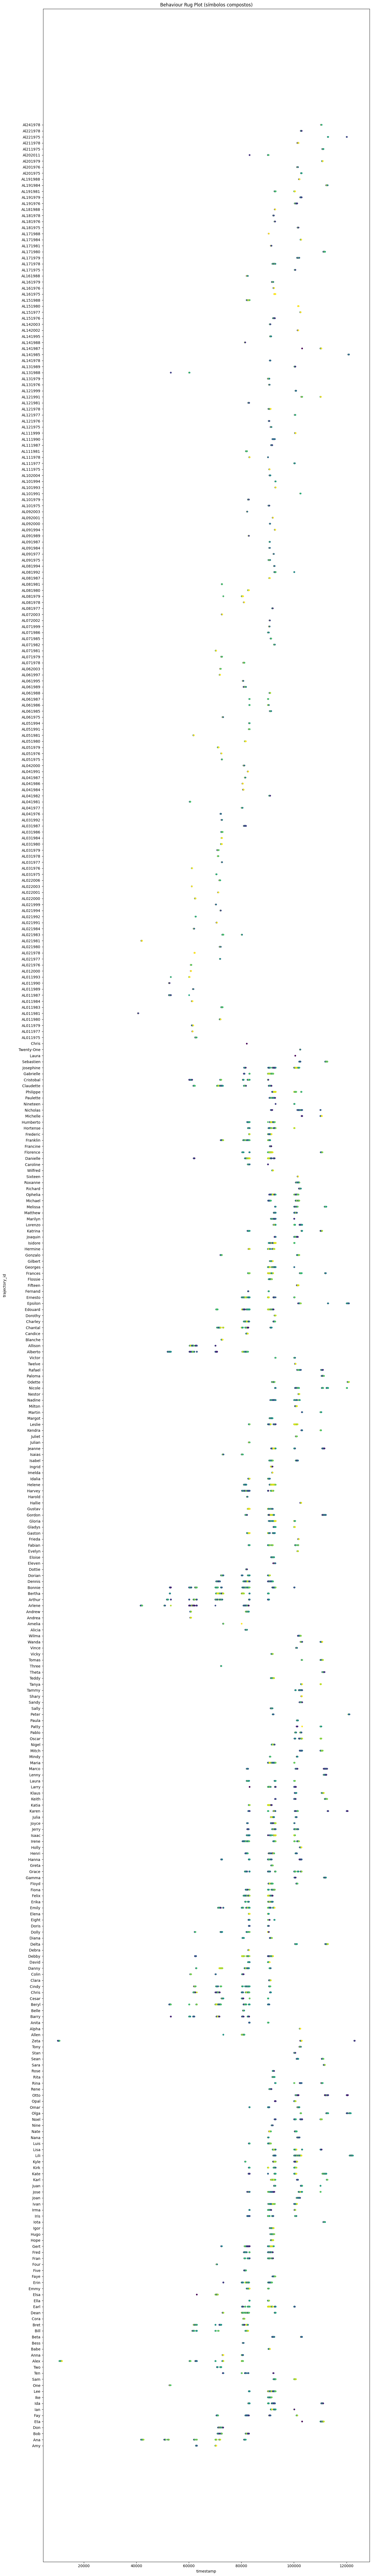

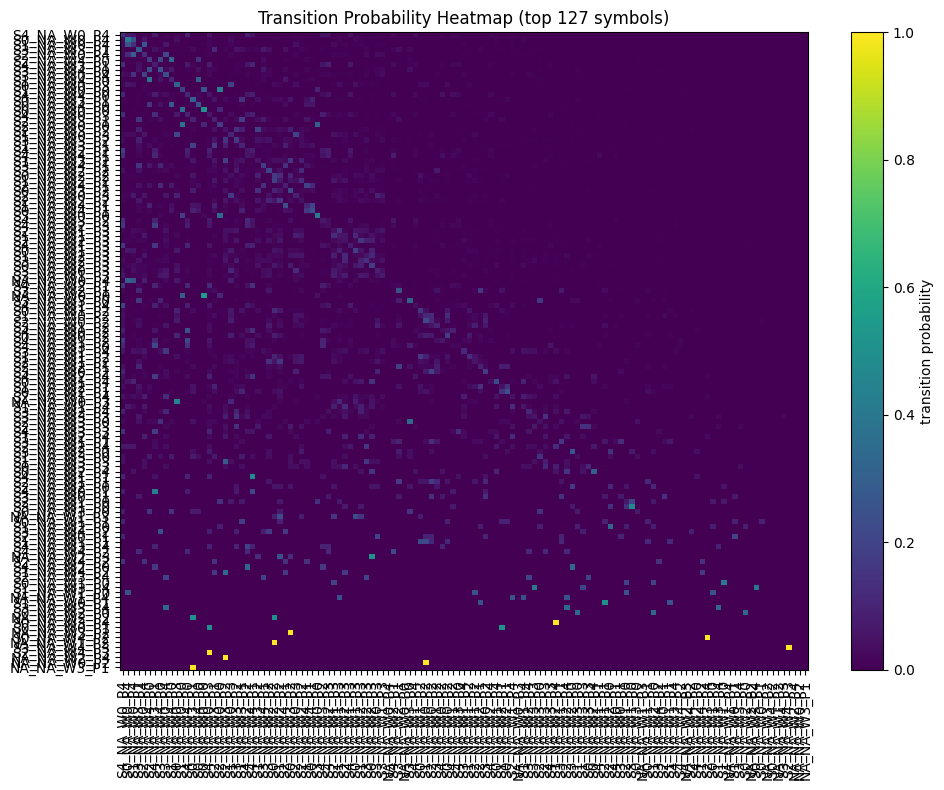

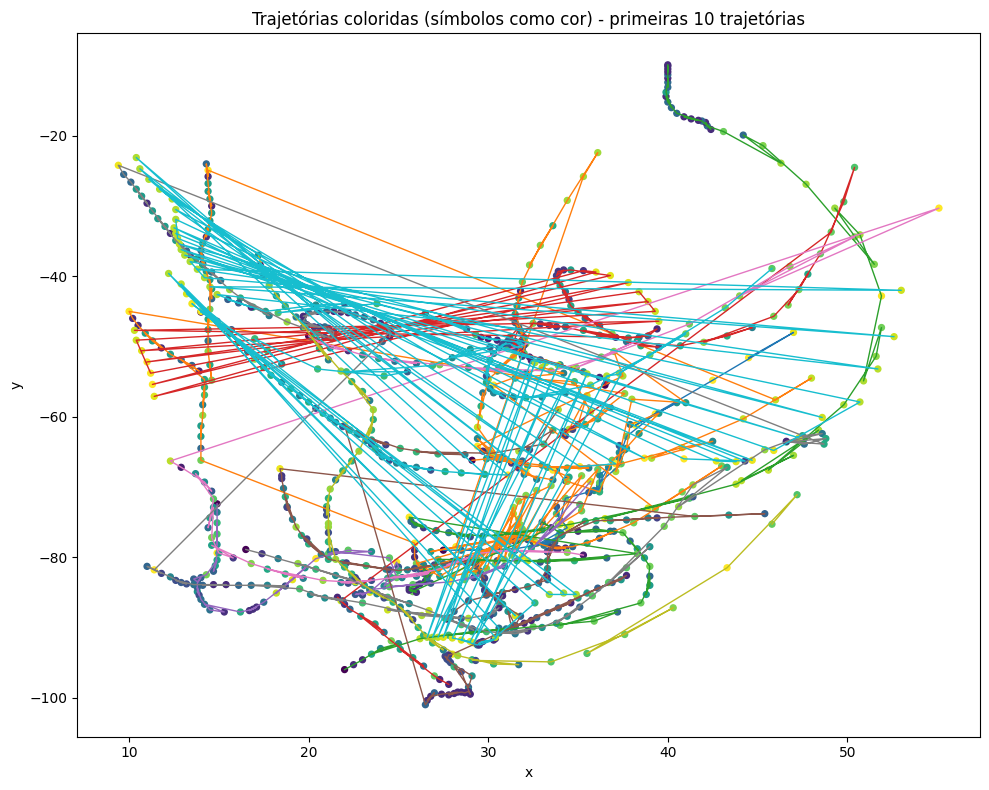

Visualizações geradas:
 - Behaviour rug: behaviour_visuals\behaviour_rug.png
 - Transition heatmap: behaviour_visuals\transition_heatmap.png
 - Trajectories colored: behaviour_visuals\trajectories_colored.png
 - Resumo (top 100 symbols): behaviour_visuals\symbol_summary_top100.csv


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import defaultdict, Counter

# Diretório de saída
OUT_DIR = "behaviour_visuals"
os.makedirs(OUT_DIR, exist_ok=True)

# Caminho dos dados processados
proc_path = "behaviour_outputs/storms_with_symbols.csv"
raw_path = "storms.csv"

# ---------------------------
# 🔵 1) CARREGAR COM ROBUSTEZ
# ---------------------------
if os.path.exists(proc_path):
    df = pd.read_csv(proc_path)
else:
    df = pd.read_csv(raw_path)

    # Renomeação mínima
    if "trajectory_id" not in df.columns and "name" in df.columns:
        df = df.rename(columns={"name": "trajectory_id"})

    # Criar timestamp se não houver
    if "timestamp" not in df.columns:
        df = df.sort_values("trajectory_id")
        df["timestamp"] = df.groupby("trajectory_id").cumcount()

    # Criar símbolo dummy se não existir
    if "symbol" not in df.columns:
        df["symbol"] = "S0_N_W0_P0"

# Garantir ordenação
sort_cols = [c for c in ["trajectory_id", "timestamp"] if c in df.columns]
df = df.sort_values(sort_cols).reset_index(drop=True)

# ---------------------------
# 🔵 2) BEHAVIOUR RUG PLOT
# ---------------------------
max_trajs = 500  # pode aumentar
ids = df["trajectory_id"].unique()[:max_trajs]
df_rug = df[df["trajectory_id"].isin(ids)].copy()

symbols = sorted(df_rug["symbol"].dropna().unique())
symbol_to_int = {s: i for i, s in enumerate(symbols)}
df_rug["symbol_int"] = df_rug["symbol"].map(symbol_to_int)

plt.figure(figsize=(14, max(6, len(ids)*0.25)))
for i, tid in enumerate(ids):
    seg = df_rug[df_rug["trajectory_id"] == tid]
    plt.scatter(seg["timestamp"], [i]*len(seg), s=12, c=seg["symbol_int"])

plt.yticks(range(len(ids)), ids)
plt.xlabel("timestamp")
plt.ylabel("trajectory_id")
plt.title("Behaviour Rug Plot (símbolos compostos)")
plt.tight_layout()

rug_path = os.path.join(OUT_DIR, "behaviour_rug.png")
plt.savefig(rug_path, dpi=150)
plt.show()
plt.close()

# ---------------------------
# 🔵 3) HEATMAP DE TRANSIÇÃO
# ---------------------------
seqs = df.groupby("trajectory_id")["symbol"].apply(list)

transition_counts = defaultdict(Counter)
for symbols_list in seqs:
    cleaned = [s for s in symbols_list if s and s != 'NA']
    for a, b in zip(cleaned, cleaned[1:]):
        transition_counts[a][b] += 1

symbol_counts = df["symbol"].value_counts()
top_k = 300
top_symbols = list(symbol_counts.index[:top_k])

mat = np.zeros((len(top_symbols), len(top_symbols)), dtype=float)
idx = {s: i for i, s in enumerate(top_symbols)}

for a, counter in transition_counts.items():
    if a not in idx:
        continue
    for b, cnt in counter.items():
        if b not in idx:
            continue
        mat[idx[a], idx[b]] = cnt

# Normalizar para probabilidades
row_sums = mat.sum(axis=1, keepdims=True)
mat_prob = np.divide(mat, np.where(row_sums == 0, 1, row_sums))

plt.figure(figsize=(10, 8))
plt.imshow(mat_prob, aspect='auto')
plt.colorbar(label="transition probability")
plt.xticks(range(len(top_symbols)), top_symbols, rotation=90)
plt.yticks(range(len(top_symbols)), top_symbols)
plt.title(f"Transition Probability Heatmap (top {len(top_symbols)} symbols)")
plt.tight_layout()

heatmap_path = os.path.join(OUT_DIR, "transition_heatmap.png")
plt.savefig(heatmap_path, dpi=150)
plt.show()
plt.close()

# ---------------------------
# 🔵 4) TRAJETÓRIAS COLORIDAS
# ---------------------------
# Garantir colunas x,y
if "x" not in df.columns or "y" not in df.columns:
    if "lat" in df.columns and "long" in df.columns:
        df = df.rename(columns={"lat":"x", "long":"y"})
    else:
        df["x"] = np.nan
        df["y"] = np.nan

traj_plot_ids = df["trajectory_id"].unique()[:10]

plt.figure(figsize=(10, 8))
for tid in traj_plot_ids:
    seg = df[df["trajectory_id"] == tid].sort_values("timestamp")

    if seg["x"].isna().all() or seg["y"].isna().all():
        continue

    seg_symbols = seg["symbol"].map(lambda s: symbol_to_int.get(s, 0))

    plt.plot(seg["x"], seg["y"], linewidth=1)
    plt.scatter(seg["x"], seg["y"], s=18, c=seg_symbols)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajetórias coloridas (símbolos como cor) - primeiras 10 trajetórias")
plt.tight_layout()

traj_path = os.path.join(OUT_DIR, "trajectories_colored.png")
plt.savefig(traj_path, dpi=150)
plt.show()
plt.close()

# ---------------------------
# 🔵 5) RESUMO TOP 100 SÍMBOLOS
# ---------------------------
summary_df = pd.DataFrame({
    "symbol": symbol_counts.index[:100],
    "count": symbol_counts.values[:100]
})
summary_csv = os.path.join(OUT_DIR, "symbol_summary_top100.csv")
summary_df.to_csv(summary_csv, index=False)

print("Visualizações geradas:")
print(" - Behaviour rug:", rug_path)
print(" - Transition heatmap:", heatmap_path)
print(" - Trajectories colored:", traj_path)
print(" - Resumo (top 100 symbols):", summary_csv)
